# Кейс 7. Построение аддитивной модели по мотивам теоремы Колмогорова

**Студент:** Карташов Игорь Олегович  
**Группа:** J3212  
**Тема:** восстановление регрессионной зависимости через аддитивную модель

В работе рассматривается задача восстановления неизвестной зависимости

$$
y = f(x_1, \ldots, x_p) + \varepsilon, \qquad x_j \in [0,1].
$$

Теорема Колмогорова о представлении непрерывных функций мотивирует использование моделей, в которых многомерная функция строится через суммы и суперпозиции одномерных функций. В данной лабораторной работе используется вычислительно реализуемый частный случай — **аддитивная модель**:

$$
\hat f(x) = \beta_0 + \sum_{j=1}^{p} g_j(x_j).
$$

Главная цель работы — исследовать, насколько такая модель способна восстанавливать нелинейные зависимости по данным, как она сравнивается с линейной и полной нелинейной моделью, а также как число базисных функций влияет на качество аппроксимации.

## 1. Постановка вычислительного эксперимента

В ноутбуке последовательно выполняются следующие шаги:

1. Генерация синтетических аддитивных данных.
2. Построение блочной матрицы признаков для аддитивной модели.
3. Оценка параметров методом наименьших квадратов и ridge-регрессией.
4. Центрирование компонент $\hat g_j$ для однозначной интерпретации.
5. Сравнение с линейной регрессией.
6. Сравнение с полной полиномиальной моделью с взаимодействиями.
7. Исследование влияния числа базисных функций.
8. Отдельный эксперимент на неаддитивных данных, где присутствуют взаимодействия между признаками.

Код в работе используется как инструмент для проведения эксперимента. Основной акцент делается на постановке задачи, методе, интерпретации результатов и выводах.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.precision", 6)

## 2. Метрики качества

Для сравнения моделей используются стандартные метрики регрессии:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat y_i)^2,
$$

$$
RMSE = \sqrt{MSE},
$$

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat y_i)^2}{\sum_{i=1}^{n}(y_i - \bar y)^2}.
$$

Чем меньше MSE и RMSE, тем точнее прогноз. Чем ближе $R^2$ к единице, тем большая доля дисперсии целевой переменной объясняется моделью.

In [2]:
def regression_metrics(y_true, y_pred):
    """Возвращает основные метрики качества регрессии."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return {
        "MSE": float(mse),
        "RMSE": rmse,
        "R2": float(r2),
    }


def metrics_to_row(model_name, train_metrics, test_metrics, n_parameters=None):
    """Преобразует словари метрик в строку таблицы."""
    row = {
        "model": model_name,
        "train_MSE": train_metrics["MSE"],
        "test_MSE": test_metrics["MSE"],
        "train_RMSE": train_metrics["RMSE"],
        "test_RMSE": test_metrics["RMSE"],
        "train_R2": train_metrics["R2"],
        "test_R2": test_metrics["R2"],
    }
    if n_parameters is not None:
        row["n_parameters"] = n_parameters
    return row

## 3. Синтетические аддитивные данные

Сначала рассмотрим задачу, где истинная зависимость действительно является аддитивной:

$$
y_i = \sin(2\pi x_{i1}) + 0.5(x_{i2} - 0.5)^2 + \exp(-3x_{i3}) + \varepsilon_i,
$$

где

$$
x_{ij} \sim U[0,1], \qquad \varepsilon_i \sim N(0, \sigma^2).
$$

Истинная функция имеет вид

$$
f(x_1,x_2,x_3) = g_1(x_1) + g_2(x_2) + g_3(x_3),
$$

поэтому аддитивная модель должна быть хорошо согласована со структурой данных.

In [3]:
def true_g1(t):
    return np.sin(2 * np.pi * t)


def true_g2(t):
    return 0.5 * (t - 0.5) ** 2


def true_g3(t):
    return np.exp(-3 * t)


def generate_additive_data(n_samples=1500, noise_std=0.10, random_state=42):
    """Генерирует синтетические данные с аддитивной истинной зависимостью."""
    rng = np.random.default_rng(random_state)
    X = rng.uniform(0, 1, size=(n_samples, 3))
    y_clean = true_g1(X[:, 0]) + true_g2(X[:, 1]) + true_g3(X[:, 2])
    noise = rng.normal(0, noise_std, size=n_samples)
    y = y_clean + noise
    return X, y, y_clean


X_add, y_add, y_add_clean = generate_additive_data(
    n_samples=1500,
    noise_std=0.10,
    random_state=RANDOM_STATE,
)

X_train_add, X_test_add, y_train_add, y_test_add = train_test_split(
    X_add,
    y_add,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print("Размер обучающей выборки:", X_train_add.shape)
print("Размер тестовой выборки:", X_test_add.shape)
print("Минимумы признаков:", X_add.min(axis=0))
print("Максимумы признаков:", X_add.max(axis=0))

Размер обучающей выборки: (1125, 3)
Размер тестовой выборки: (375, 3)
Минимумы признаков: [0.00056813 0.0006423  0.00051874]
Максимумы признаков: [0.99940893 0.99939004 0.99976534]


## 4. Визуализация истинных компонент

На синтетических данных известны истинные компоненты $g_1$, $g_2$, $g_3$. Это позволяет проверить не только точность прогноза, но и качество восстановления отдельных вкладов признаков.

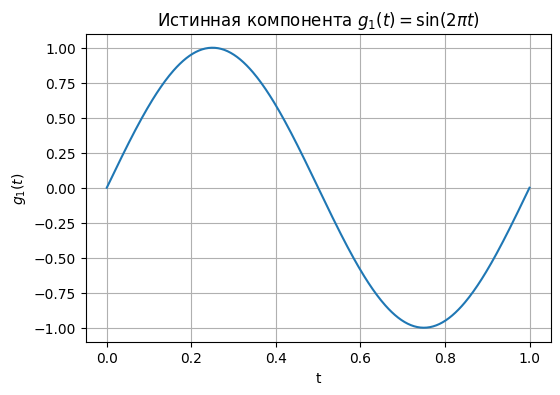

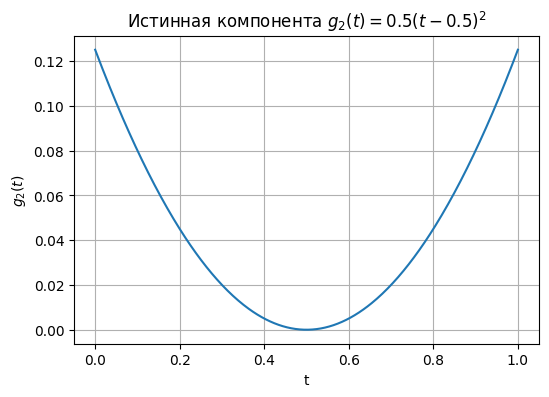

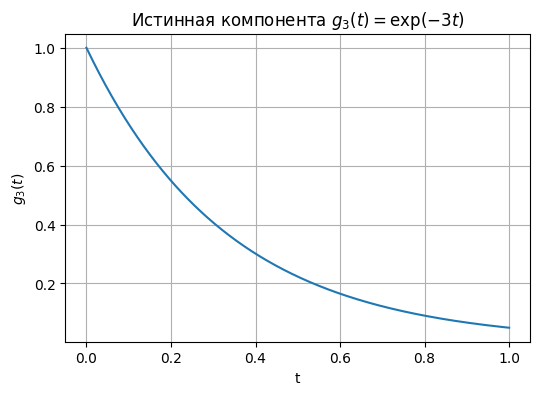

In [4]:
t_grid = np.linspace(0, 1, 400)
true_functions = [true_g1, true_g2, true_g3]
component_names = [r"$g_1(t)=\sin(2\pi t)$", r"$g_2(t)=0.5(t-0.5)^2$", r"$g_3(t)=\exp(-3t)$"]

for idx, func in enumerate(true_functions, start=1):
    plt.figure(figsize=(6, 4))
    plt.plot(t_grid, func(t_grid))
    plt.xlabel("t")
    plt.ylabel(rf"$g_{idx}(t)$")
    plt.title(f"Истинная компонента {component_names[idx - 1]}")
    plt.grid(True)
    plt.show()

## 5. Базисное представление компонент

Каждая неизвестная одномерная компонента представляется в конечном базисе:

$$
g_j(t) = \sum_{m=1}^{M} a_{jm}\psi_m(t).
$$

В качестве основного варианта используется полиномиальный базис без отдельной константы внутри каждой компоненты:

$$
\psi_1(t)=t, \qquad \psi_2(t)=t^2, \qquad \ldots, \qquad \psi_M(t)=t^M.
$$

Свободный член учитывается отдельно как $\beta_0$. После подстановки базисного разложения получаем модель

$$
\hat f(x)=\beta_0+\sum_{j=1}^{p}\sum_{m=1}^{M}a_{jm}\psi_m(x_j),
$$

которая является линейной по параметрам $\beta_0$ и $a_{jm}$.

In [5]:
def polynomial_basis_1d(x, degree):
    """Строит полиномиальный базис [x, x^2, ..., x^degree] для одномерного массива."""
    x = np.asarray(x)
    return np.column_stack([x ** m for m in range(1, degree + 1)])


def build_additive_design_matrix(X, degree, include_intercept=True):
    """
    Строит блочную матрицу признаков Z для аддитивной модели.
    
    Для каждого признака x_j добавляется блок [x_j, x_j^2, ..., x_j^degree].
    Если include_intercept=True, первым столбцом добавляется единичный столбец.
    """
    X = np.asarray(X)
    n_samples, n_features = X.shape
    blocks = [polynomial_basis_1d(X[:, j], degree) for j in range(n_features)]
    Z = np.hstack(blocks)
    if include_intercept:
        Z = np.hstack([np.ones((n_samples, 1)), Z])
    return Z


def count_additive_parameters(n_features, degree):
    """Число параметров аддитивной модели с полиномиальным базисом."""
    return 1 + n_features * degree

## 6. Оценка параметров: МНК и ridge-регрессия

После построения матрицы $Z$ задача сводится к линейной регрессии:

$$
\hat y = Z\theta.
$$

Для МНК решается задача

$$
\min_{\theta}\|y-Z\theta\|^2.
$$

Для ridge-регрессии добавляется штраф на величину коэффициентов:

$$
\min_{\theta}\left(\|y-Z\theta\|^2 + \lambda \|\theta\|^2\right).
$$

Свободный член $\beta_0$ не регуляризуется, поэтому для него штраф в матрице регуляризации равен нулю.

In [6]:
def fit_design_matrix_regression(Z, y, alpha=0.0):
    """
    Оценивает theta по МНК или ridge-регрессии.
    
    alpha=0 соответствует МНК.
    alpha>0 соответствует ridge-регрессии.
    Первый коэффициент считается свободным членом и не регуляризуется.
    """
    Z = np.asarray(Z)
    y = np.asarray(y)
    n_params = Z.shape[1]
    penalty = np.eye(n_params)
    penalty[0, 0] = 0.0
    theta = np.linalg.solve(Z.T @ Z + alpha * penalty, Z.T @ y)
    return theta


def predict_design_matrix(Z, theta):
    """Возвращает прогнозы по матрице Z и вектору параметров theta."""
    return np.asarray(Z) @ np.asarray(theta)

## 7. Обучение аддитивной модели на аддитивных данных

Выберем начальное число базисных функций $M=7$. Это достаточно гибкий базис, который способен приблизить синусоидальную и экспоненциальную компоненты, но ещё не является чрезмерно сложным.

In [7]:
degree_main = 7
ridge_alpha = 1e-3

Z_train_add = build_additive_design_matrix(X_train_add, degree_main, include_intercept=True)
Z_test_add = build_additive_design_matrix(X_test_add, degree_main, include_intercept=True)

theta_add_ols = fit_design_matrix_regression(Z_train_add, y_train_add, alpha=0.0)
theta_add_ridge = fit_design_matrix_regression(Z_train_add, y_train_add, alpha=ridge_alpha)

y_pred_train_add_ols = predict_design_matrix(Z_train_add, theta_add_ols)
y_pred_test_add_ols = predict_design_matrix(Z_test_add, theta_add_ols)

y_pred_train_add_ridge = predict_design_matrix(Z_train_add, theta_add_ridge)
y_pred_test_add_ridge = predict_design_matrix(Z_test_add, theta_add_ridge)

metrics_add_ols_train = regression_metrics(y_train_add, y_pred_train_add_ols)
metrics_add_ols_test = regression_metrics(y_test_add, y_pred_test_add_ols)

metrics_add_ridge_train = regression_metrics(y_train_add, y_pred_train_add_ridge)
metrics_add_ridge_test = regression_metrics(y_test_add, y_pred_test_add_ridge)

print("Размер матрицы Z_train:", Z_train_add.shape)
print("Число параметров аддитивной модели:", count_additive_parameters(X_train_add.shape[1], degree_main))
print("Метрики аддитивной модели, МНК, test:", metrics_add_ols_test)
print("Метрики аддитивной модели, Ridge, test:", metrics_add_ridge_test)

Размер матрицы Z_train: (1125, 22)
Число параметров аддитивной модели: 22
Метрики аддитивной модели, МНК, test: {'MSE': 0.010822545859627266, 'RMSE': 0.1040314657189221, 'R2': 0.9818558113241662}
Метрики аддитивной модели, Ridge, test: {'MSE': 0.011024471373940555, 'RMSE': 0.1049974827028751, 'R2': 0.9815172796443115}


## 8. Центрирование и восстановление компонент

Без дополнительных ограничений разложение не является единственным: константу можно переносить между $\beta_0$ и отдельными функциями $g_j$. Для интерпретации компонент используем центрирование на обучающей выборке:

$$
\sum_{i=1}^{\ell} g_j(x_{ij})=0, \qquad j=1,\ldots,p.
$$

После обучения вычисляем среднее значение каждой компоненты на train-выборке, вычитаем его из компоненты и добавляем сумму средних к свободному члену.

In [8]:
def split_additive_theta(theta, n_features, degree):
    """Разделяет theta на свободный член и коэффициенты компонент."""
    beta0 = float(theta[0])
    component_coefs = []
    start = 1
    for _ in range(n_features):
        end = start + degree
        component_coefs.append(np.asarray(theta[start:end]))
        start = end
    return beta0, component_coefs


def evaluate_component(t, coefs):
    """Вычисляет значение компоненты по её коэффициентам в полиномиальном базисе."""
    basis = polynomial_basis_1d(t, len(coefs))
    return basis @ coefs


def center_additive_components(theta, X_train, degree):
    """Центрирует компоненты аддитивной модели на обучающей выборке."""
    n_features = X_train.shape[1]
    beta0, component_coefs = split_additive_theta(theta, n_features, degree)
    component_means = []
    
    for j, coefs in enumerate(component_coefs):
        values = evaluate_component(X_train[:, j], coefs)
        component_means.append(float(values.mean()))
    
    beta0_centered = beta0 + float(np.sum(component_means))
    return beta0_centered, component_coefs, component_means


beta0_centered, component_coefs, component_means = center_additive_components(
    theta_add_ridge,
    X_train_add,
    degree_main,
)

print("Исходный свободный член beta0:", split_additive_theta(theta_add_ridge, 3, degree_main)[0])
print("Средние компонент на train:", component_means)
print("Свободный член после центрирования:", beta0_centered)

Исходный свободный член beta0: 1.0337632622308919
Средние компонент на train: [0.09448778863926868, -0.07951426518923298, -0.6679544835327779]
Свободный член после центрирования: 0.3807823021481497


## 9. Сравнение истинных и восстановленных компонент

Поскольку данные синтетические, можно сравнить оценённые функции $\hat g_j(t)$ с истинными $g_j(t)$. Для корректного сравнения обе функции центрируются на обучающей выборке.

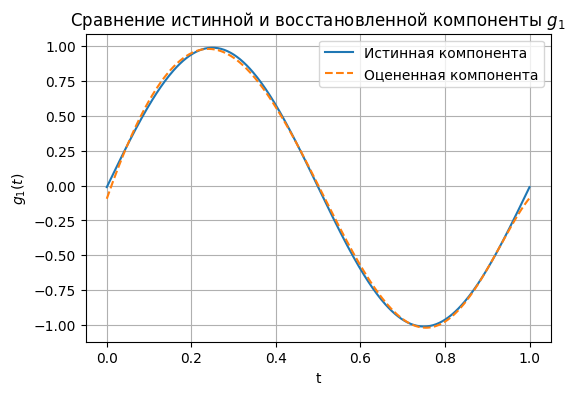

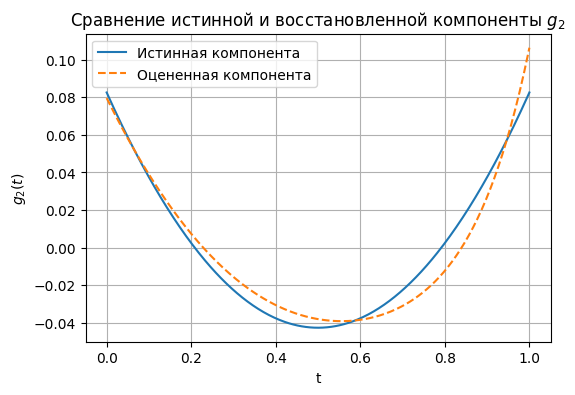

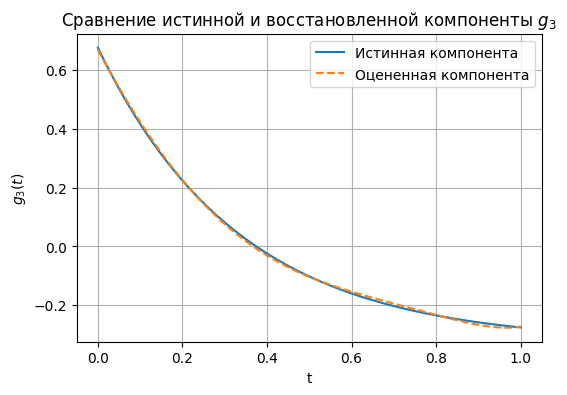

In [9]:
for j in range(3):
    g_hat = evaluate_component(t_grid, component_coefs[j])
    g_hat_centered = g_hat - component_means[j]
    
    true_values = true_functions[j](t_grid)
    true_mean = true_functions[j](X_train_add[:, j]).mean()
    true_values_centered = true_values - true_mean
    
    plt.figure(figsize=(6, 4))
    plt.plot(t_grid, true_values_centered, label="Истинная компонента")
    plt.plot(t_grid, g_hat_centered, linestyle="--", label="Оцененная компонента")
    plt.xlabel("t")
    plt.ylabel(rf"$g_{j + 1}(t)$")
    plt.title(rf"Сравнение истинной и восстановленной компоненты $g_{j + 1}$")
    plt.grid(True)
    plt.legend()
    plt.show()

## 10. Линейная модель для сравнения

Линейная регрессия является частным случаем аддитивной модели:

$$
\hat y_{lin} = \beta_0 + \sum_{j=1}^{p}\beta_jx_j.
$$

Она проста и интерпретируема, но не способна гибко восстанавливать нелинейные компоненты.

In [10]:
linear_add = LinearRegression()
linear_add.fit(X_train_add, y_train_add)

y_pred_train_linear_add = linear_add.predict(X_train_add)
y_pred_test_linear_add = linear_add.predict(X_test_add)

metrics_linear_add_train = regression_metrics(y_train_add, y_pred_train_linear_add)
metrics_linear_add_test = regression_metrics(y_test_add, y_pred_test_linear_add)

metrics_linear_add_test

{'MSE': 0.21593939971436096,
 'RMSE': 0.46469280144452524,
 'R2': 0.637973794541298}

## 11. Полная полиномиальная модель с взаимодействиями

В качестве более общей модели сравнения используется полиномиальная регрессия с взаимодействиями:

$$
\hat y_{full}=\beta_0+\sum_j\beta_jx_j+\sum_{j\le k}\beta_{jk}x_jx_k+\ldots
$$

Такая модель менее интерпретируема, но способна учитывать взаимодействия между признаками.

In [11]:
full_poly_degree_add = 5

full_poly_add = Pipeline([
    ("poly", PolynomialFeatures(degree=full_poly_degree_add, include_bias=True)),
    ("ridge", Ridge(alpha=1e-3, fit_intercept=False)),
])

full_poly_add.fit(X_train_add, y_train_add)

y_pred_train_full_add = full_poly_add.predict(X_train_add)
y_pred_test_full_add = full_poly_add.predict(X_test_add)

metrics_full_add_train = regression_metrics(y_train_add, y_pred_train_full_add)
metrics_full_add_test = regression_metrics(y_test_add, y_pred_test_full_add)

full_poly_n_params_add = full_poly_add.named_steps["poly"].n_output_features_
print("Число параметров полной полиномиальной модели:", full_poly_n_params_add)
metrics_full_add_test

Число параметров полной полиномиальной модели: 56


{'MSE': 0.013018480546218679,
 'RMSE': 0.11409855628455023,
 'R2': 0.9781742881603832}

## 12. Сводная таблица качества на аддитивных данных

Сравним линейную модель, аддитивную модель и полную полиномиальную модель на данных, где истинная зависимость является аддитивной.

In [12]:
results_additive = pd.DataFrame([
    metrics_to_row(
        "Linear regression",
        metrics_linear_add_train,
        metrics_linear_add_test,
        n_parameters=X_train_add.shape[1] + 1,
    ),
    metrics_to_row(
        f"Additive OLS, M={degree_main}",
        metrics_add_ols_train,
        metrics_add_ols_test,
        n_parameters=count_additive_parameters(X_train_add.shape[1], degree_main),
    ),
    metrics_to_row(
        f"Additive Ridge, M={degree_main}",
        metrics_add_ridge_train,
        metrics_add_ridge_test,
        n_parameters=count_additive_parameters(X_train_add.shape[1], degree_main),
    ),
    metrics_to_row(
        f"Full polynomial Ridge, degree={full_poly_degree_add}",
        metrics_full_add_train,
        metrics_full_add_test,
        n_parameters=full_poly_n_params_add,
    ),
])

results_additive

,model,train_MSE,test_MSE,train_RMSE,test_RMSE,train_R2,test_R2,n_parameters
0,Linear regression,0.205242,0.215939,0.453036,0.464693,0.663554,0.637974,4
1,"Additive OLS, M=7",0.009728,0.010823,0.098631,0.104031,0.984053,0.981856,22
2,"Additive Ridge, M=7",0.010130,0.011024,0.100647,0.104997,0.983395,0.981517,22
3,"Full polynomial Ridge, degree=5",0.012308,0.013018,0.110941,0.114099,0.979824,0.978174,56


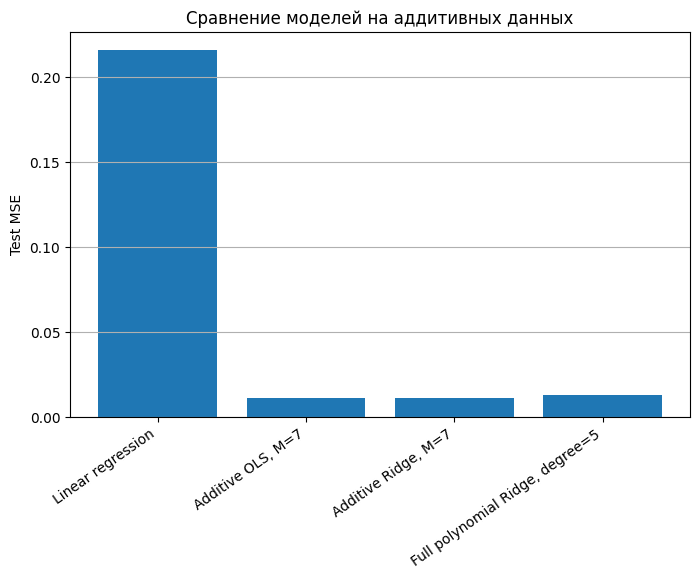

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(results_additive["model"], results_additive["test_MSE"])
plt.ylabel("Test MSE")
plt.title("Сравнение моделей на аддитивных данных")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.show()

## 13. График истинных и предсказанных значений

Если модель хорошо описывает данные, точки на графике должны располагаться вблизи диагональной линии $\hat y = y$.

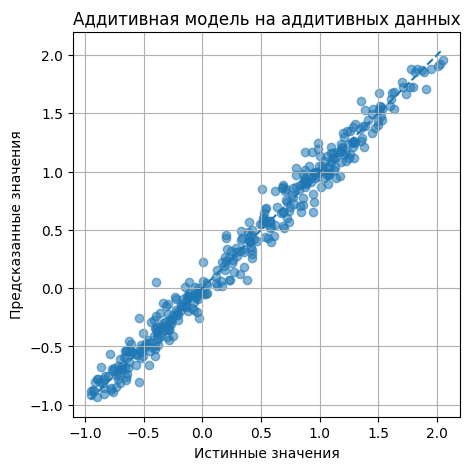

In [14]:
def plot_true_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.55)
    min_value = min(float(np.min(y_true)), float(np.min(y_pred)))
    max_value = max(float(np.max(y_true)), float(np.max(y_pred)))
    plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
    plt.xlabel("Истинные значения")
    plt.ylabel("Предсказанные значения")
    plt.title(title)
    plt.grid(True)
    plt.show()


plot_true_vs_pred(
    y_test_add,
    y_pred_test_add_ridge,
    "Аддитивная модель на аддитивных данных",
)

## 14. Влияние числа базисных функций

Число базисных функций $M$ определяет сложность аддитивной модели. При малом $M$ модель может недообучаться, а при слишком большом $M$ — переобучаться или становиться численно менее устойчивой.

Проведём перебор нескольких значений $M$ и сравним ошибки на обучающей и тестовой выборках.

In [15]:
degree_grid = [1, 2, 3, 5, 7, 10, 12, 15]
complexity_rows = []

for degree in degree_grid:
    Z_train = build_additive_design_matrix(X_train_add, degree, include_intercept=True)
    Z_test = build_additive_design_matrix(X_test_add, degree, include_intercept=True)
    theta = fit_design_matrix_regression(Z_train, y_train_add, alpha=1e-3)
    
    y_train_pred = predict_design_matrix(Z_train, theta)
    y_test_pred = predict_design_matrix(Z_test, theta)
    
    train_metrics = regression_metrics(y_train_add, y_train_pred)
    test_metrics = regression_metrics(y_test_add, y_test_pred)
    
    complexity_rows.append({
        "M": degree,
        "n_parameters": count_additive_parameters(X_train_add.shape[1], degree),
        "train_MSE": train_metrics["MSE"],
        "test_MSE": test_metrics["MSE"],
        "train_R2": train_metrics["R2"],
        "test_R2": test_metrics["R2"],
    })

complexity_df = pd.DataFrame(complexity_rows)
complexity_df

,M,n_parameters,train_MSE,test_MSE,train_R2,test_R2
0,1,4,0.205242,0.215939,0.663554,0.637975
1,2,7,0.193621,0.200119,0.682604,0.664497
2,3,10,0.014344,0.014310,0.976486,0.976009
3,5,16,0.012664,0.012774,0.979241,0.978584
4,7,22,0.010130,0.011024,0.983395,0.981517
5,10,31,0.010157,0.011400,0.983350,0.980888
6,12,37,0.010050,0.011224,0.983525,0.981182
7,15,46,0.010023,0.011139,0.983570,0.981326


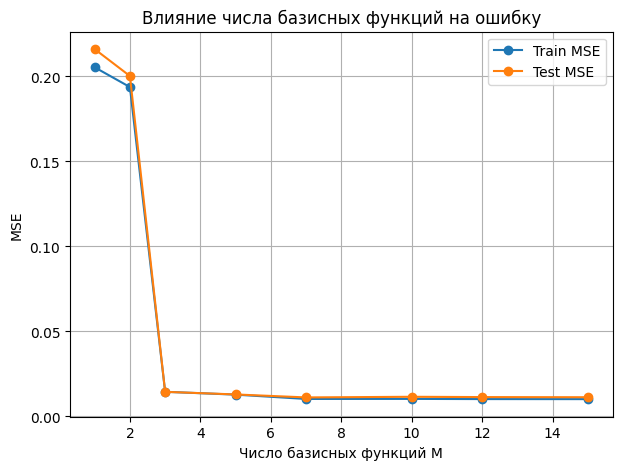

In [16]:
plt.figure(figsize=(7, 5))
plt.plot(complexity_df["M"], complexity_df["train_MSE"], marker="o", label="Train MSE")
plt.plot(complexity_df["M"], complexity_df["test_MSE"], marker="o", label="Test MSE")
plt.xlabel("Число базисных функций M")
plt.ylabel("MSE")
plt.title("Влияние числа базисных функций на ошибку")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
best_complexity_row = complexity_df.loc[complexity_df["test_MSE"].idxmin()]
print("Лучшее значение M по test MSE:")
print(best_complexity_row)

Лучшее значение M по test MSE:
M                7.000000
n_parameters    22.000000
train_MSE        0.010130
test_MSE         0.011024
train_R2         0.983395
test_R2          0.981517
Name: 4, dtype: float64


## 15. Неаддитивные данные

Теперь рассмотрим функцию, где присутствует взаимодействие между признаками:

$$
y_i = \sin(2\pi(x_{i1}+x_{i2})) + 0.5x_{i3} + \varepsilon_i.
$$

Эта зависимость не является аддитивной относительно $x_1$ и $x_2$, поскольку они входят в функцию совместно. Поэтому аддитивная модель должна столкнуться с ограничением: она пытается представить зависимость в виде суммы $g_1(x_1)+g_2(x_2)+g_3(x_3)$, хотя истинная функция содержит взаимодействие.

In [18]:
def generate_nonadditive_data(n_samples=1500, noise_std=0.10, random_state=42):
    """Генерирует синтетические данные с неаддитивной истинной зависимостью."""
    rng = np.random.default_rng(random_state)
    X = rng.uniform(0, 1, size=(n_samples, 3))
    y_clean = np.sin(2 * np.pi * (X[:, 0] + X[:, 1])) + 0.5 * X[:, 2]
    noise = rng.normal(0, noise_std, size=n_samples)
    y = y_clean + noise
    return X, y, y_clean


X_nonadd, y_nonadd, y_nonadd_clean = generate_nonadditive_data(
    n_samples=1500,
    noise_std=0.10,
    random_state=RANDOM_STATE,
)

X_train_nonadd, X_test_nonadd, y_train_nonadd, y_test_nonadd = train_test_split(
    X_nonadd,
    y_nonadd,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print("Размер обучающей выборки:", X_train_nonadd.shape)
print("Размер тестовой выборки:", X_test_nonadd.shape)

Размер обучающей выборки: (1125, 3)
Размер тестовой выборки: (375, 3)


## 16. Обучение моделей на неаддитивных данных

Сравним три модели:

1. Линейную регрессию.
2. Аддитивную ridge-модель.
3. Полную полиномиальную ridge-модель с взаимодействиями.

Ожидается, что полная модель будет лучше справляться с неаддитивной зависимостью, поскольку она содержит признаки взаимодействия.

In [19]:
# 1. Линейная модель
linear_nonadd = LinearRegression()
linear_nonadd.fit(X_train_nonadd, y_train_nonadd)

y_pred_train_linear_nonadd = linear_nonadd.predict(X_train_nonadd)
y_pred_test_linear_nonadd = linear_nonadd.predict(X_test_nonadd)

metrics_linear_nonadd_train = regression_metrics(y_train_nonadd, y_pred_train_linear_nonadd)
metrics_linear_nonadd_test = regression_metrics(y_test_nonadd, y_pred_test_linear_nonadd)

# 2. Аддитивная модель
degree_nonadd = 10
Z_train_nonadd = build_additive_design_matrix(X_train_nonadd, degree_nonadd, include_intercept=True)
Z_test_nonadd = build_additive_design_matrix(X_test_nonadd, degree_nonadd, include_intercept=True)

theta_nonadd_ridge = fit_design_matrix_regression(Z_train_nonadd, y_train_nonadd, alpha=1e-3)

y_pred_train_add_nonadd = predict_design_matrix(Z_train_nonadd, theta_nonadd_ridge)
y_pred_test_add_nonadd = predict_design_matrix(Z_test_nonadd, theta_nonadd_ridge)

metrics_add_nonadd_train = regression_metrics(y_train_nonadd, y_pred_train_add_nonadd)
metrics_add_nonadd_test = regression_metrics(y_test_nonadd, y_pred_test_add_nonadd)

# 3. Полная модель с взаимодействиями
full_poly_degree_nonadd = 7
full_poly_nonadd = Pipeline([
    ("poly", PolynomialFeatures(degree=full_poly_degree_nonadd, include_bias=True)),
    ("ridge", Ridge(alpha=1e-3, fit_intercept=False)),
])

full_poly_nonadd.fit(X_train_nonadd, y_train_nonadd)

y_pred_train_full_nonadd = full_poly_nonadd.predict(X_train_nonadd)
y_pred_test_full_nonadd = full_poly_nonadd.predict(X_test_nonadd)

metrics_full_nonadd_train = regression_metrics(y_train_nonadd, y_pred_train_full_nonadd)
metrics_full_nonadd_test = regression_metrics(y_test_nonadd, y_pred_test_full_nonadd)

full_poly_n_params_nonadd = full_poly_nonadd.named_steps["poly"].n_output_features_

## 17. Сводная таблица качества на неаддитивных данных

In [20]:
results_nonadditive = pd.DataFrame([
    metrics_to_row(
        "Linear regression",
        metrics_linear_nonadd_train,
        metrics_linear_nonadd_test,
        n_parameters=X_train_nonadd.shape[1] + 1,
    ),
    metrics_to_row(
        f"Additive Ridge, M={degree_nonadd}",
        metrics_add_nonadd_train,
        metrics_add_nonadd_test,
        n_parameters=count_additive_parameters(X_train_nonadd.shape[1], degree_nonadd),
    ),
    metrics_to_row(
        f"Full polynomial Ridge, degree={full_poly_degree_nonadd}",
        metrics_full_nonadd_train,
        metrics_full_nonadd_test,
        n_parameters=full_poly_n_params_nonadd,
    ),
])

results_nonadditive

,model,train_MSE,test_MSE,train_RMSE,test_RMSE,train_R2,test_R2,n_parameters
0,Linear regression,0.508063,0.516059,0.712786,0.718372,0.053742,0.083553,4
1,"Additive Ridge, M=10",0.504535,0.520233,0.710306,0.721272,0.060314,0.076140,31
2,"Full polynomial Ridge, degree=7",0.053880,0.068074,0.232120,0.260910,0.899650,0.879110,120


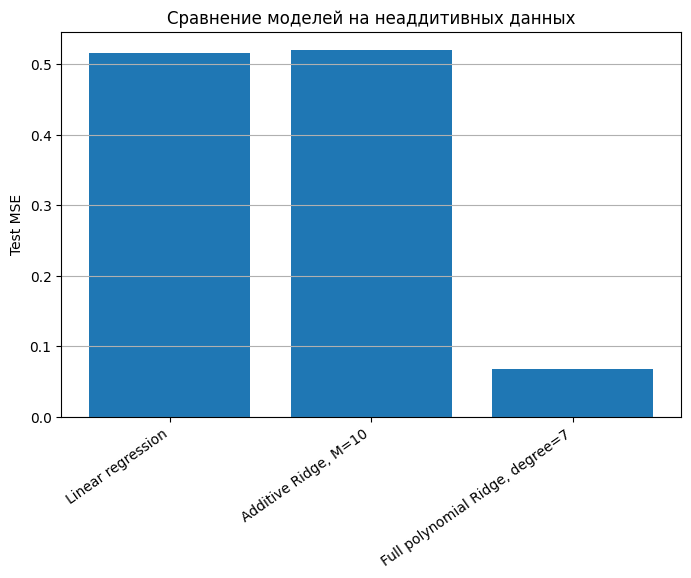

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(results_nonadditive["model"], results_nonadditive["test_MSE"])
plt.ylabel("Test MSE")
plt.title("Сравнение моделей на неаддитивных данных")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.show()

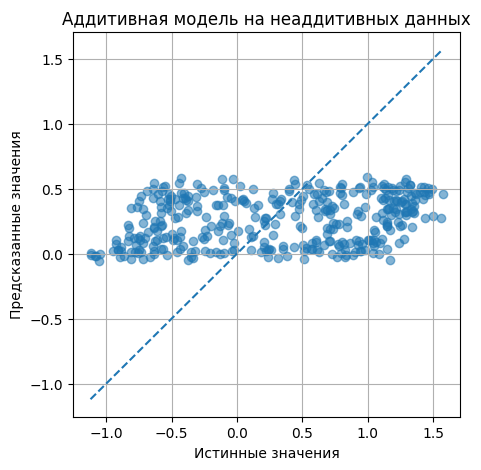

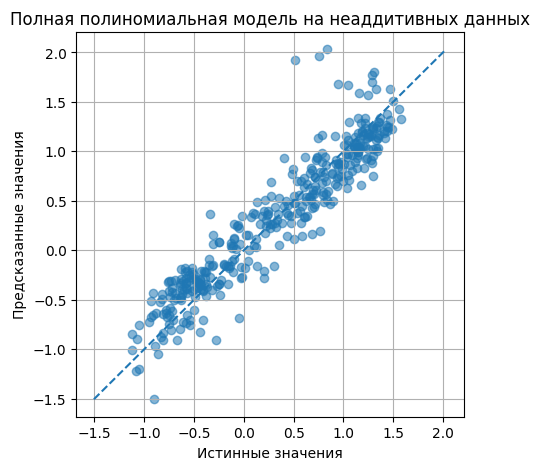

In [22]:
plot_true_vs_pred(
    y_test_nonadd,
    y_pred_test_add_nonadd,
    "Аддитивная модель на неаддитивных данных",
)

plot_true_vs_pred(
    y_test_nonadd,
    y_pred_test_full_nonadd,
    "Полная полиномиальная модель на неаддитивных данных",
)

## 18. Сравнение сложности моделей

Помимо качества важно сравнивать количество параметров. Аддитивная модель обычно имеет меньше параметров, чем полная полиномиальная модель с взаимодействиями. Это делает её более простой и интерпретируемой, но ограничивает способность описывать взаимодействия между признаками.

In [23]:
complexity_comparison = pd.DataFrame([
    {
        "experiment": "additive data",
        "model": "Linear regression",
        "n_parameters": X_train_add.shape[1] + 1,
    },
    {
        "experiment": "additive data",
        "model": f"Additive Ridge, M={degree_main}",
        "n_parameters": count_additive_parameters(X_train_add.shape[1], degree_main),
    },
    {
        "experiment": "additive data",
        "model": f"Full polynomial, degree={full_poly_degree_add}",
        "n_parameters": full_poly_n_params_add,
    },
    {
        "experiment": "nonadditive data",
        "model": "Linear regression",
        "n_parameters": X_train_nonadd.shape[1] + 1,
    },
    {
        "experiment": "nonadditive data",
        "model": f"Additive Ridge, M={degree_nonadd}",
        "n_parameters": count_additive_parameters(X_train_nonadd.shape[1], degree_nonadd),
    },
    {
        "experiment": "nonadditive data",
        "model": f"Full polynomial, degree={full_poly_degree_nonadd}",
        "n_parameters": full_poly_n_params_nonadd,
    },
])

complexity_comparison

,experiment,model,n_parameters
0,additive data,Linear regression,4
1,additive data,"Additive Ridge, M=7",22
2,additive data,"Full polynomial, degree=5",56
3,nonadditive data,Linear regression,4
4,nonadditive data,"Additive Ridge, M=10",31
5,nonadditive data,"Full polynomial, degree=7",120


## 19. Итоговые исследовательские выводы

Ниже выводы формируются на основе фактически полученных таблиц метрик.

In [24]:
def best_model_name(results_df):
    idx = results_df["test_MSE"].idxmin()
    return results_df.loc[idx, "model"], results_df.loc[idx, "test_MSE"], results_df.loc[idx, "test_R2"]

best_add_name, best_add_mse, best_add_r2 = best_model_name(results_additive)
best_nonadd_name, best_nonadd_mse, best_nonadd_r2 = best_model_name(results_nonadditive)

add_linear_mse = float(results_additive.loc[results_additive["model"] == "Linear regression", "test_MSE"].iloc[0])
add_model_mse = float(results_additive.loc[results_additive["model"].str.startswith("Additive Ridge"), "test_MSE"].iloc[0])
nonadd_add_mse = float(results_nonadditive.loc[results_nonadditive["model"].str.startswith("Additive Ridge"), "test_MSE"].iloc[0])
nonadd_full_mse = float(results_nonadditive.loc[results_nonadditive["model"].str.startswith("Full polynomial"), "test_MSE"].iloc[0])

print("ИТОГОВЫЕ ВЫВОДЫ")
print("-" * 80)
print(f"1. На аддитивных данных лучшая модель по test MSE: {best_add_name}.")
print(f"   Test MSE = {best_add_mse:.6f}, test R2 = {best_add_r2:.6f}.")
print(f"2. Аддитивная ridge-модель имеет test MSE = {add_model_mse:.6f},")
print(f"   тогда как линейная регрессия имеет test MSE = {add_linear_mse:.6f}.")
print("   Это показывает преимущество нелинейных одномерных компонент над линейной зависимостью.")
print(f"3. Лучшее значение M по эксперименту сложности: M = {int(best_complexity_row['M'])},")
print(f"   test MSE = {best_complexity_row['test_MSE']:.6f}.")
print("4. Графики восстановленных компонент показывают, что аддитивная модель позволяет интерпретировать")
print("   вклад каждого признака отдельно, что является её преимуществом перед полной полиномиальной моделью.")
print(f"5. На неаддитивных данных лучшая модель по test MSE: {best_nonadd_name}.")
print(f"   Test MSE = {best_nonadd_mse:.6f}, test R2 = {best_nonadd_r2:.6f}.")
print(f"6. Для неаддитивной зависимости аддитивная модель имеет test MSE = {nonadd_add_mse:.6f},")
print(f"   а полная модель с взаимодействиями имеет test MSE = {nonadd_full_mse:.6f}.")
print("   Это подтверждает ограничение аддитивной модели: она плохо описывает взаимодействия признаков.")

ИТОГОВЫЕ ВЫВОДЫ
--------------------------------------------------------------------------------
1. На аддитивных данных лучшая модель по test MSE: Additive OLS, M=7.
   Test MSE = 0.010823, test R2 = 0.981856.
2. Аддитивная ridge-модель имеет test MSE = 0.011024,
   тогда как линейная регрессия имеет test MSE = 0.215939.
   Это показывает преимущество нелинейных одномерных компонент над линейной зависимостью.
3. Лучшее значение M по эксперименту сложности: M = 7,
   test MSE = 0.011024.
4. Графики восстановленных компонент показывают, что аддитивная модель позволяет интерпретировать
   вклад каждого признака отдельно, что является её преимуществом перед полной полиномиальной моделью.
5. На неаддитивных данных лучшая модель по test MSE: Full polynomial Ridge, degree=7.
   Test MSE = 0.068074, test R2 = 0.879110.
6. Для неаддитивной зависимости аддитивная модель имеет test MSE = 0.520233,
   а полная модель с взаимодействиями имеет test MSE = 0.068074.
   Это подтверждает ограничение ад

## 20. Заключение

В лабораторной работе была реализована аддитивная регрессионная модель вида

$$
\hat f(x)=\beta_0+\sum_{j=1}^{p}g_j(x_j),
$$

где каждая компонента $g_j$ аппроксимировалась конечным полиномиальным базисом. После базисного разложения задача была сведена к оценке параметров в линейной модели по расширенной матрице признаков $Z$.

На синтетических аддитивных данных модель показала преимущество над обычной линейной регрессией, поскольку смогла восстановить нелинейные одномерные компоненты. При этом модель сохранила интерпретируемость: для каждого признака можно построить отдельную функцию вклада $\hat g_j(t)$.

На неаддитивных данных, где целевая переменная зависела от совместного выражения $x_1+x_2$, качество аддитивной модели оказалось ограниченным. Полная полиномиальная модель с взаимодействиями лучше учитывала такую структуру, но имела больше параметров и хуже интерпретировалась.

Таким образом, аддитивная модель является компромиссом между простой линейной регрессией и более сложными нелинейными моделями: она хорошо работает, когда зависимость близка к сумме одномерных эффектов, но требует расширения при наличии существенных взаимодействий между признаками.

**Ссылка на репозиторий с кодом:** `TODO: вставить ссылку на GitHub-репозиторий`.